In [1]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_DIR = PROJECT_ROOT / "classification" / "train"
VAL_DIR   = PROJECT_ROOT / "classification" / "val"
TEST_DIR  = PROJECT_ROOT / "classification" / "test"


print("TRAIN:", TRAIN_DIR)
print("VAL  :", VAL_DIR)
print("TEST :", TEST_DIR)

TRAIN: c:\defect_cnn_project\classification\train
VAL  : c:\defect_cnn_project\classification\val
TEST : c:\defect_cnn_project\classification\test


In [2]:

IMG_SIZE = 224
BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [3]:
import torchvision.models as models
from torch import nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_classes = len(class_names)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Šimon/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


In [4]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def eval_model(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item() * X.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [5]:
EPOCHS = 20
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = eval_model(model, val_loader)

    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train_acc={train_acc:.3f} val_acc={val_acc:.3f} | "
          f"train_loss={train_loss:.3f} val_loss={val_loss:.3f}")

Epoch 1/20 | train_acc=0.771 val_acc=0.933 | train_loss=0.653 val_loss=0.258
Epoch 2/20 | train_acc=0.976 val_acc=0.971 | train_loss=0.109 val_loss=0.075
Epoch 3/20 | train_acc=0.991 val_acc=0.990 | train_loss=0.040 val_loss=0.047
Epoch 4/20 | train_acc=0.996 val_acc=0.990 | train_loss=0.026 val_loss=0.039
Epoch 5/20 | train_acc=0.991 val_acc=0.990 | train_loss=0.035 val_loss=0.036
Epoch 6/20 | train_acc=0.998 val_acc=1.000 | train_loss=0.016 val_loss=0.018
Epoch 7/20 | train_acc=0.998 val_acc=0.990 | train_loss=0.010 val_loss=0.059
Epoch 8/20 | train_acc=0.996 val_acc=0.971 | train_loss=0.012 val_loss=0.080
Epoch 9/20 | train_acc=0.994 val_acc=0.990 | train_loss=0.017 val_loss=0.025
Epoch 10/20 | train_acc=0.998 val_acc=1.000 | train_loss=0.012 val_loss=0.022
Epoch 11/20 | train_acc=0.999 val_acc=0.990 | train_loss=0.004 val_loss=0.021
Epoch 12/20 | train_acc=0.999 val_acc=1.000 | train_loss=0.006 val_loss=0.012
Epoch 13/20 | train_acc=0.998 val_acc=0.990 | train_loss=0.005 val_loss=0

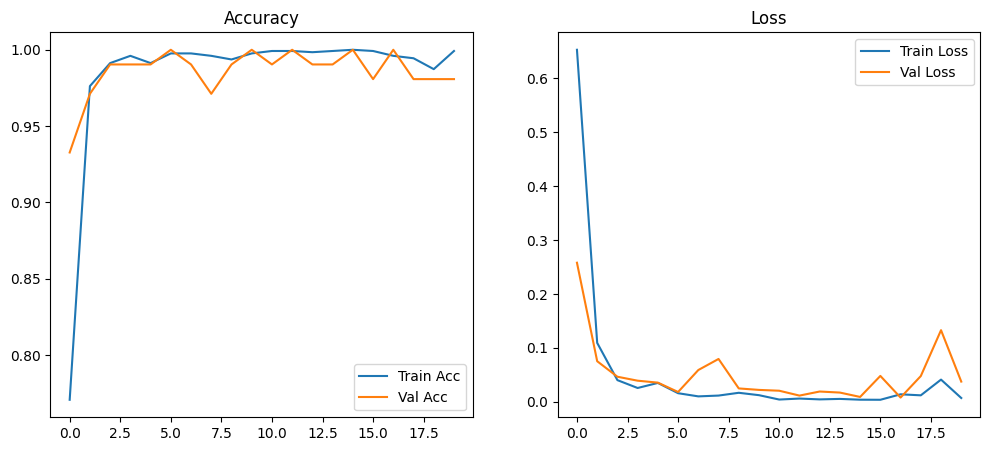

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.legend(); plt.title("Loss")

plt.show()

Test accuracy: 0.990990990990991
              precision    recall  f1-score   support

        bad1       1.00      1.00      1.00        18
        bad2       1.00      1.00      1.00        12
        bad3       0.95      1.00      0.98        20
        bad4       1.00      1.00      1.00        15
        good       1.00      0.98      0.99        46

    accuracy                           0.99       111
   macro avg       0.99      1.00      0.99       111
weighted avg       0.99      0.99      0.99       111



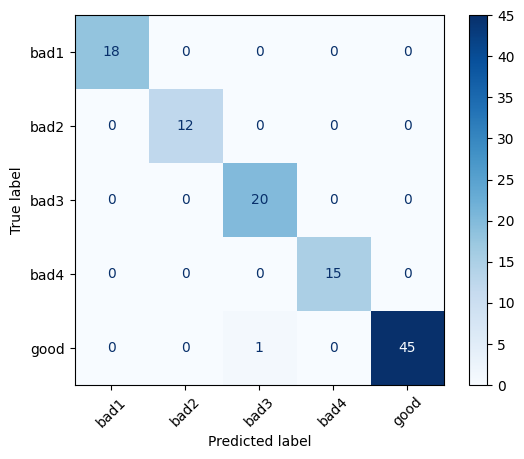

In [7]:
test_loss, test_acc = eval_model(model, test_loader)
print("Test accuracy:", test_acc)

all_true, all_pred = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_pred.extend(preds)
        all_true.extend(y.numpy())

print(classification_report(all_true, all_pred, target_names=class_names))

cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues"); plt.xticks(rotation=45); plt.show()

In [8]:

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
torch.save(model.state_dict(), MODEL_DIR / "keras_like_cnn_multiclass.pth")
